# Assignment 6: Classifying Phantoms by Ellipse Count

## Summary

**Task:** Generate two groups of random 28x28 phantoms. Group 1 contains ONE ellipse, Group 2 contains TWO ellipses. Each ellipse has random intensity, size, and orientation. Train a neural network to classify the two groups.

**Approach:**
- Use the phantom generator from the lecture to create 28x28 images with randomized ellipses
- Generate 2000 training and 500 test phantoms per class (4000 train, 1000 test total)
- Train a small CNN (Conv2D layers + Dense) to classify one-ellipse vs two-ellipse phantoms
- Output layer uses 2 neurons with softmax (one-hot strategy)

**Result:** The CNN achieves high accuracy on the test set, reliably distinguishing single-ellipse from double-ellipse phantoms.

## Phantom Generator

The `phantom()` function creates an image from a set of ellipses. Each ellipse is defined by `[I, a, b, x0, y0, phi]`:
- I = additive intensity
- a = major semi-axis length
- b = minor semi-axis length
- x0, y0 = center position (in [-1, 1] coordinates)
- phi = rotation angle in degrees

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def phantom(n=256, ellipses=None):
    """
    Create a phantom image from a set of ellipses.
    Based on Alex Opie's implementation (GPL v3).

    Each ellipse: [I, a, b, x0, y0, phi]
      I   - Additive intensity
      a   - Major semi-axis
      b   - Minor semi-axis
      x0  - Horizontal center offset
      y0  - Vertical center offset
      phi - Rotation in degrees
    Image bounding box is [-1, 1] x [-1, 1].
    """
    p = np.zeros((n, n))
    ygrid, xgrid = np.mgrid[-1:1:(1j*n), -1:1:(1j*n)]

    for ellip in ellipses:
        I   = ellip[0]
        a2  = ellip[1]**2
        b2  = ellip[2]**2
        x0  = ellip[3]
        y0  = ellip[4]
        phi = ellip[5] * np.pi / 180

        x = xgrid - x0
        y = ygrid - y0

        cos_p = np.cos(phi)
        sin_p = np.sin(phi)

        locs = (((x * cos_p + y * sin_p)**2) / a2
              + ((y * cos_p - x * sin_p)**2) / b2) <= 1

        p[locs] += I

    return p

## Generate Random Phantoms

Each ellipse gets:
- Random intensity in [0.3, 1.0]
- Random semi-axes in [0.15, 0.5] (visible at 28x28)
- Random center position in [-0.4, 0.4]
- Random rotation in [0, 180] degrees

In [2]:
def random_ellipse():
    """Generate parameters for one random ellipse."""
    I   = np.random.uniform(0.3, 1.0)
    a   = np.random.uniform(0.15, 0.5)
    b   = np.random.uniform(0.10, 0.4)
    x0  = np.random.uniform(-0.4, 0.4)
    y0  = np.random.uniform(-0.4, 0.4)
    phi = np.random.uniform(0, 180)
    return [I, a, b, x0, y0, phi]

def generate_phantom(num_ellipses, img_size=28):
    """Generate a single phantom with the given number of ellipses."""
    ellipses = [random_ellipse() for _ in range(num_ellipses)]
    P = phantom(n=img_size, ellipses=ellipses)
    P = np.maximum(0, P)  # Clip negative values
    if P.max() > 0:
        P = P / P.max()   # Normalize to [0, 1]
    return P

def generate_dataset(num_per_class, img_size=28):
    """Generate a dataset of one-ellipse and two-ellipse phantoms."""
    images = []
    labels = []

    # Group 1: ONE ellipse (label 0)
    for _ in range(num_per_class):
        images.append(generate_phantom(1, img_size))
        labels.append(0)

    # Group 2: TWO ellipses (label 1)
    for _ in range(num_per_class):
        images.append(generate_phantom(2, img_size))
        labels.append(1)

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.float32)

    # Shuffle
    idx = np.random.permutation(len(labels))
    return images[idx], labels[idx]

In [3]:
np.random.seed(42)

# Generate training data (2000 per class)
train_images, train_labels = generate_dataset(2000, img_size=28)

# Generate test data (500 per class)
test_images, test_labels = generate_dataset(500, img_size=28)

# Add channel dimension for CNN (28, 28) -> (28, 28, 1)
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

print(f"Training set: {train_images.shape}, labels: {train_labels.shape}")
print(f"Test set:     {test_images.shape}, labels: {test_labels.shape}")

Training set: (4000, 28, 28, 1), labels: (4000,)
Test set:     (1000, 28, 28, 1), labels: (1000,)


## Examples of Random Phantoms

Top row: **one-ellipse phantoms** (Group 1). Bottom row: **two-ellipse phantoms** (Group 2).

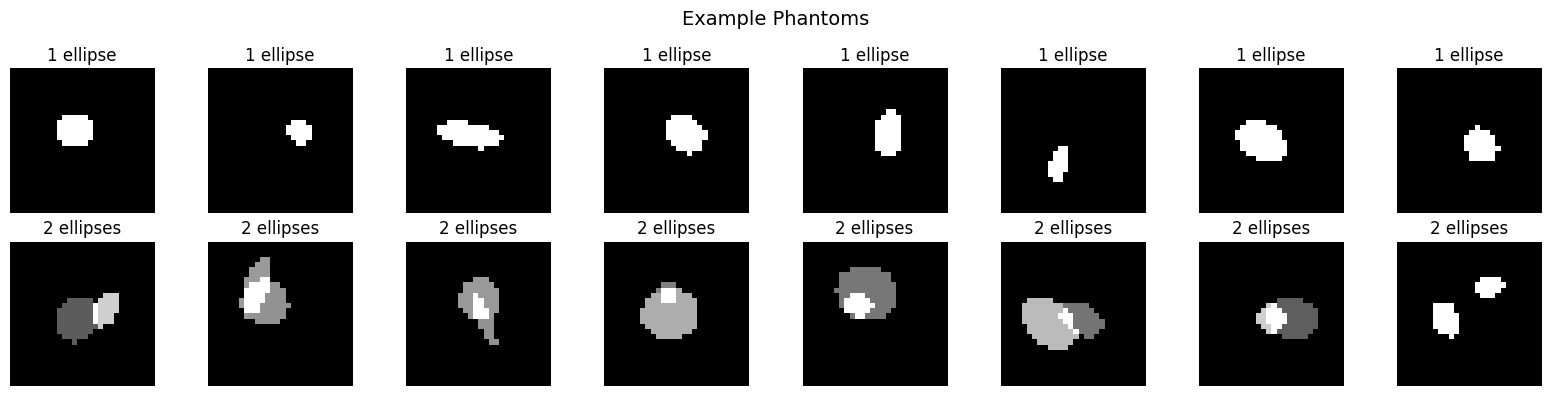

In [4]:
# Find indices for each class
one_ellipse_idx = np.where(train_labels == 0)[0]
two_ellipse_idx = np.where(train_labels == 1)[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Example Phantoms', fontsize=14)

for i in range(8):
    axes[0, i].imshow(train_images[one_ellipse_idx[i], :, :, 0],
                      cmap='Greys_r', vmin=0, vmax=1)
    axes[0, i].set_title('1 ellipse')
    axes[0, i].axis('off')

    axes[1, i].imshow(train_images[two_ellipse_idx[i], :, :, 0],
                      cmap='Greys_r', vmin=0, vmax=1)
    axes[1, i].set_title('2 ellipses')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Build and Train CNN Classifier

A small CNN appropriate for 28x28 grayscale images:
- Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> Flatten -> Dense(128) -> Dense(2, softmax)

In [5]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/Users/stephenhales/School/spring_2026/CS_6480/HW/cs-6480/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,610 (1.60 MB)

 Trainable params: 420,610 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(train_images, train_labels,
                    epochs=30,
                    batch_size=64,
                    validation_data=(test_images, test_labels))

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 215ms/step - accuracy: 0.7448 - loss: 0.5091 - val_accuracy: 0.8700 - val_loss: 0.3208
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 544ms/step - accuracy: 0.9287 - loss: 0.2069 - val_accuracy: 0.9410 - val_loss: 0.1507
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 365ms/step - accuracy: 0.9645 - loss: 0.1108 - val_accuracy: 0.9540 - val_loss: 0.1294
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9843 - loss: 0.0634 - val_accuracy: 0.9810 - val_loss: 0.0518
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.9890 - loss: 0.0425 - val_accuracy: 0.9790 - val_loss: 0.0630
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9933 - loss: 0.0317 - val_accuracy: 0.9930 - val_loss: 0.0288
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.9925 - loss: 0.0265 - val_accuracy: 0.9610 - val_loss: 0.0858
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.9847 - loss: 0.0476 - val_accurac

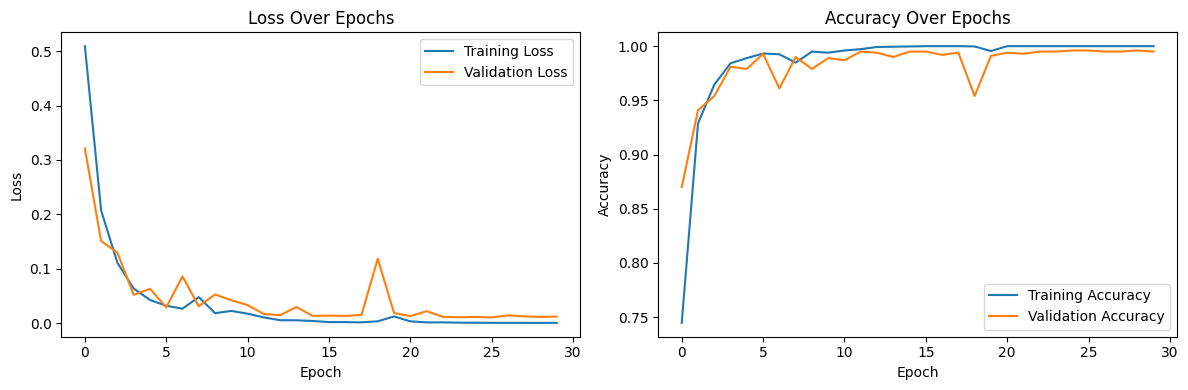

In [7]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate on Test Data

In [8]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0118 
Test accuracy: 0.9950


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


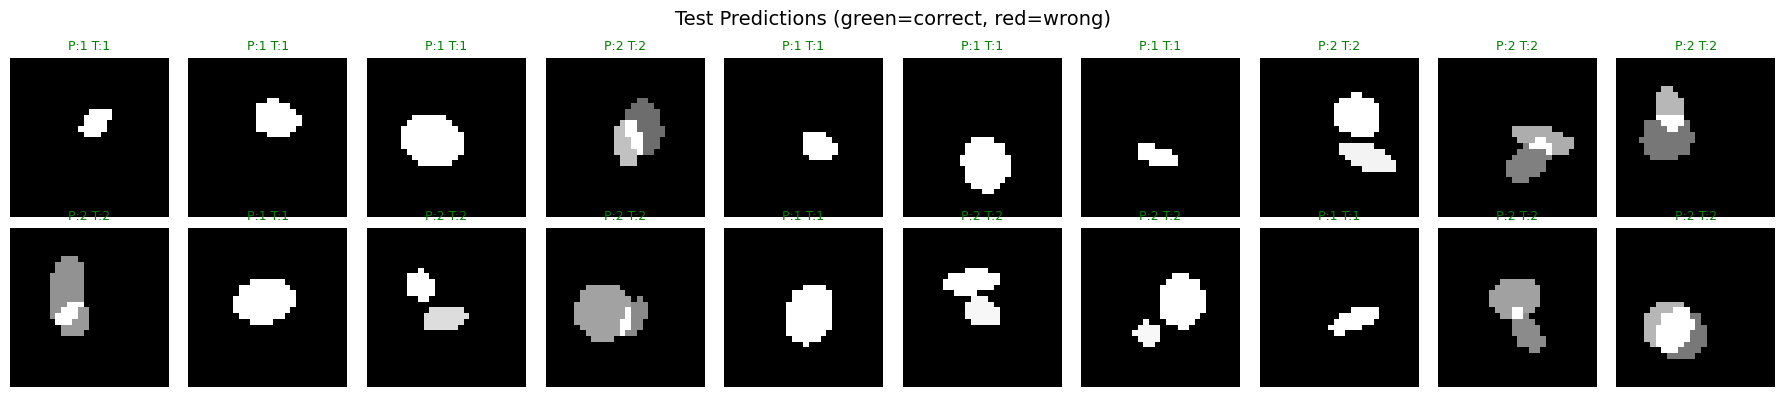

In [9]:
# Show predictions on test samples
predictions = model.predict(test_images[:20])
pred_classes = predictions.argmax(axis=1)
true_classes = test_labels[:20].astype(int)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Test Predictions (green=correct, red=wrong)', fontsize=14)

for i in range(20):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(test_images[i, :, :, 0],
                          cmap='Greys_r', vmin=0, vmax=1)
    correct = pred_classes[i] == true_classes[i]
    color = 'green' if correct else 'red'
    label_str = f'P:{pred_classes[i]+1} T:{true_classes[i]+1}'
    axes[row, col].set_title(label_str, color=color, fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()